# Q-factorisation on Gridworld Maze- Baseline, full retrain not regularisation

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy
import os


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, get_free_cells, sample_goals)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork
from trainer import dqn_train


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


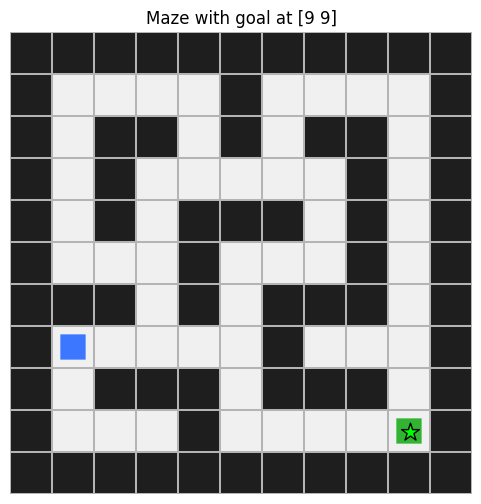

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

## Training Loop across goals

first loop = retrain from scratch for every goal

second loop = retrain from previous task weights as initialisation

Sampled GOALS: [(1, 9)]

================ SEED 42 ================


===== PASS 1 / 2 =====


----- seed=42, goal=(1, 9) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=-8.550 | eval_len=87.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=-9.875 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=-9.850 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=-9.912 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=-9.900 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.998 | Loss=0.004| Weight loss=0.000

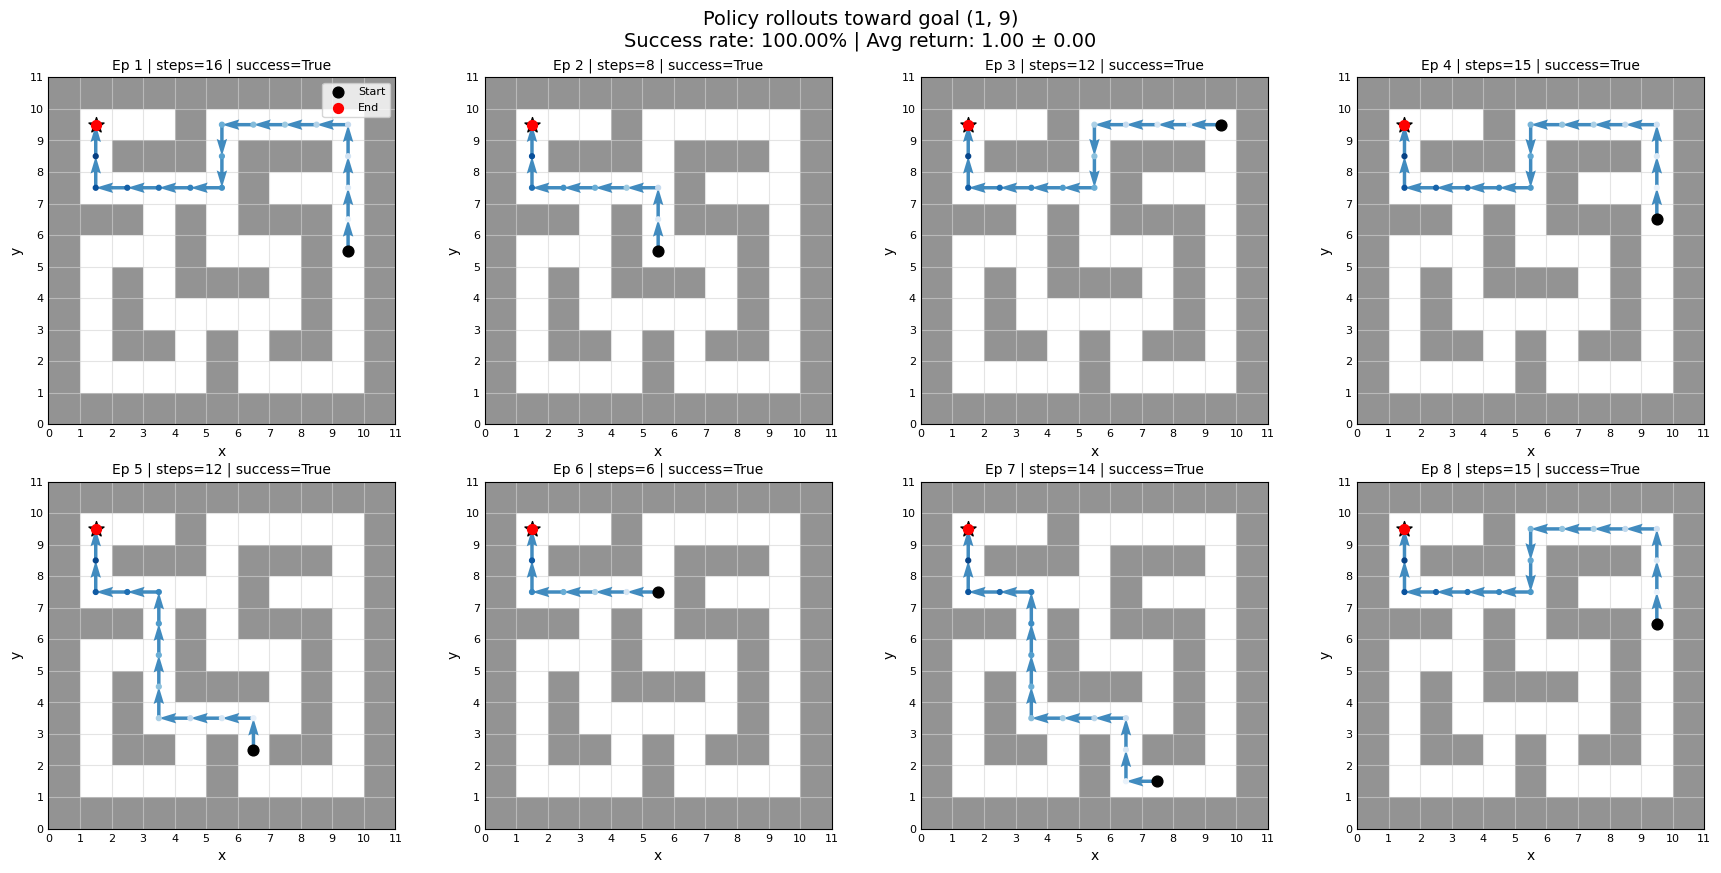

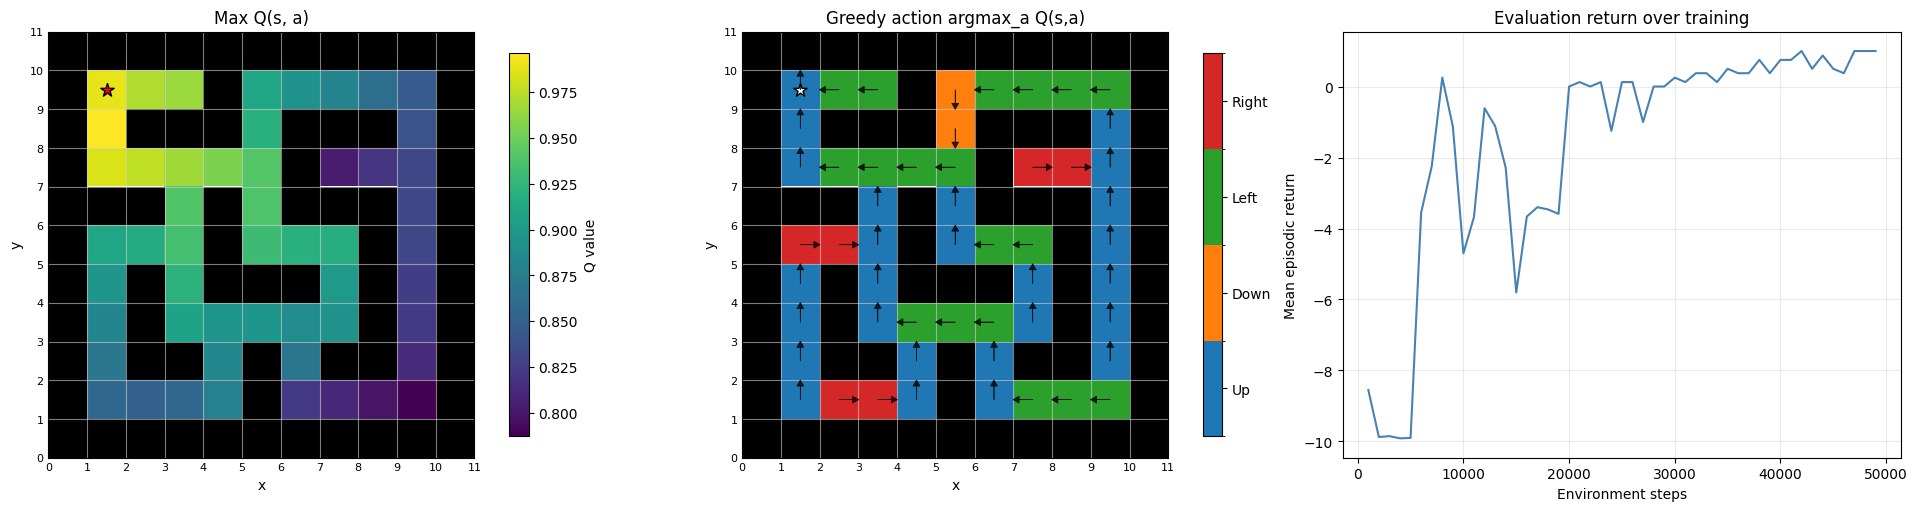

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4937227 2.8781683 2.7720215 2.351904  2.1546283]
cumulative variance (first 5 dims): [0.21120593 0.354544   0.48750445 0.5832169  0.6635462 ]
cos(phi(s,a), psi/task): mean=0.8338, std=0.0728


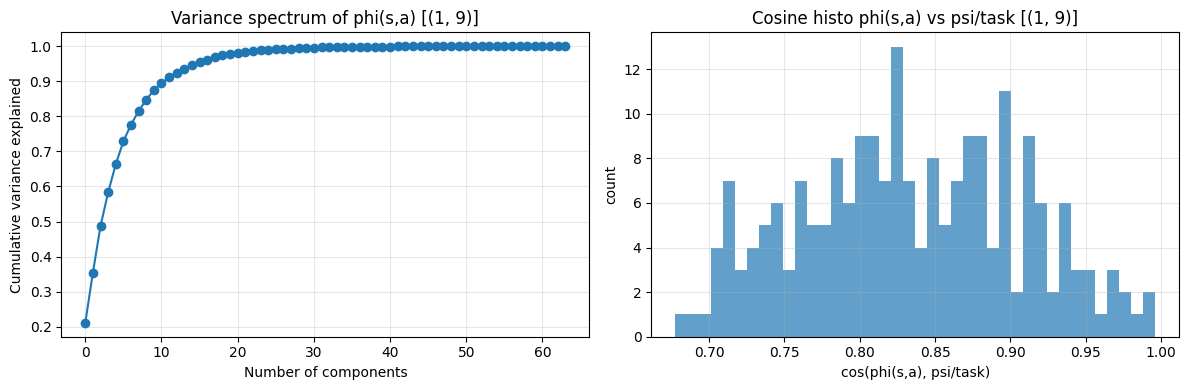


Goal embedding cosine similarity matrix:
     (1, 9)
  (1, 9)      1.000

===== PASS 2 / 2 =====


----- seed=42, goal=(1, 9) -----

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=-9.950 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=-7.112 | eval_len=75.2| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=-8.600 | eval_len=87.8| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=-9.887 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.905 | eval_return=-8.587 | eval_len=87.6| Ortho loss=0.000 | SigReg loss=0.998 | Loss=0.012| Weight loss=0

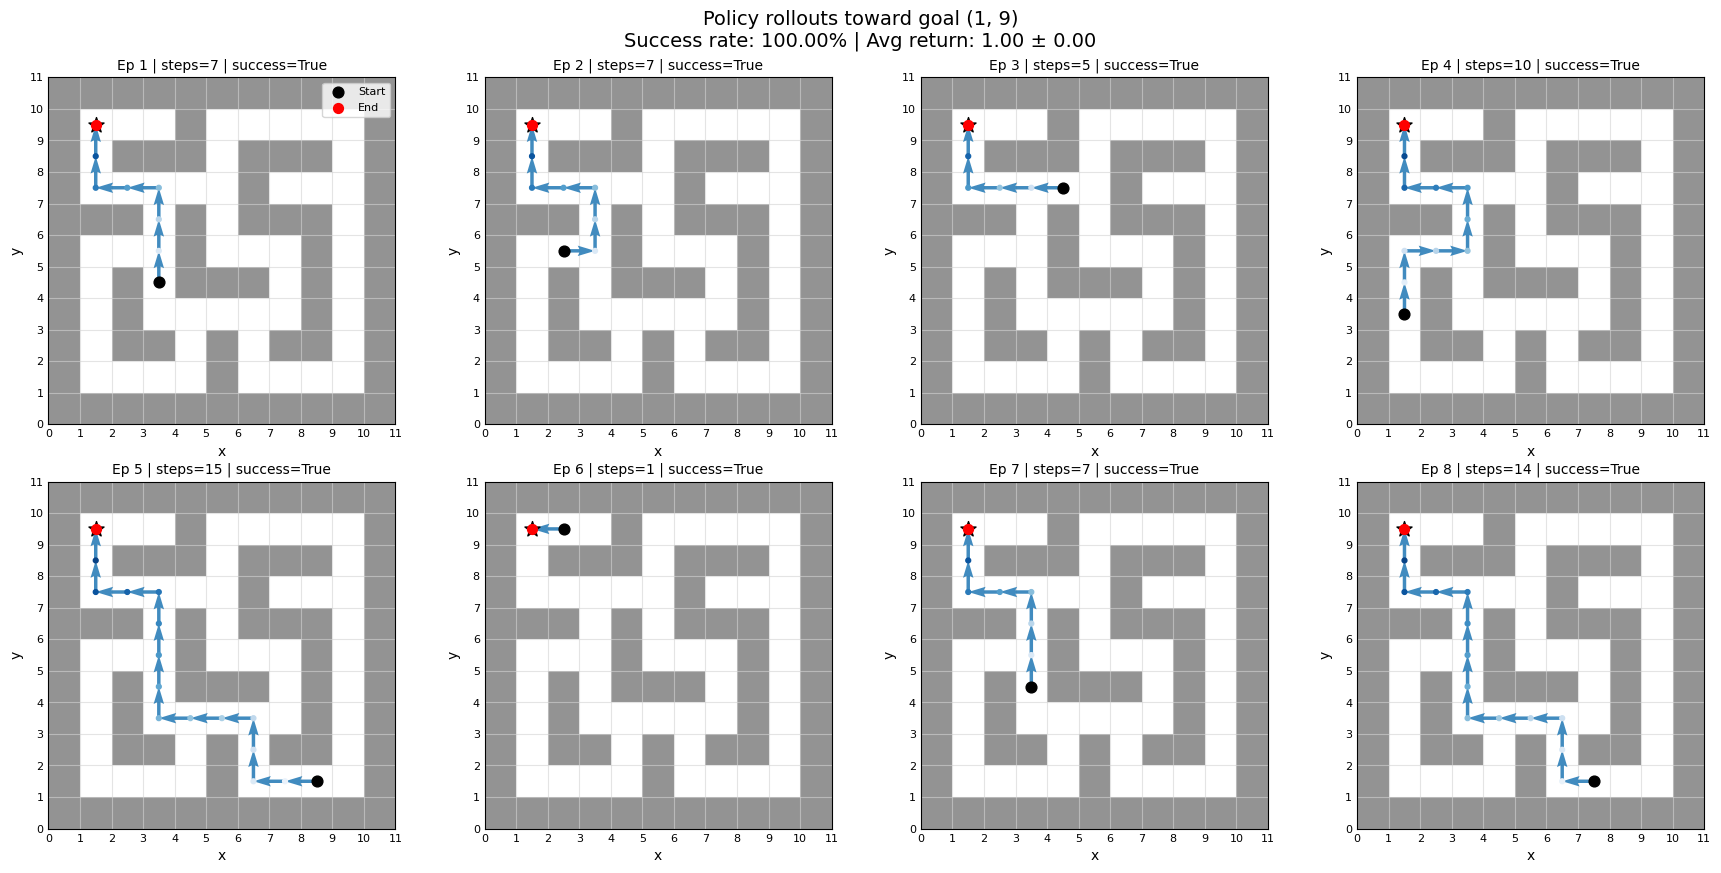

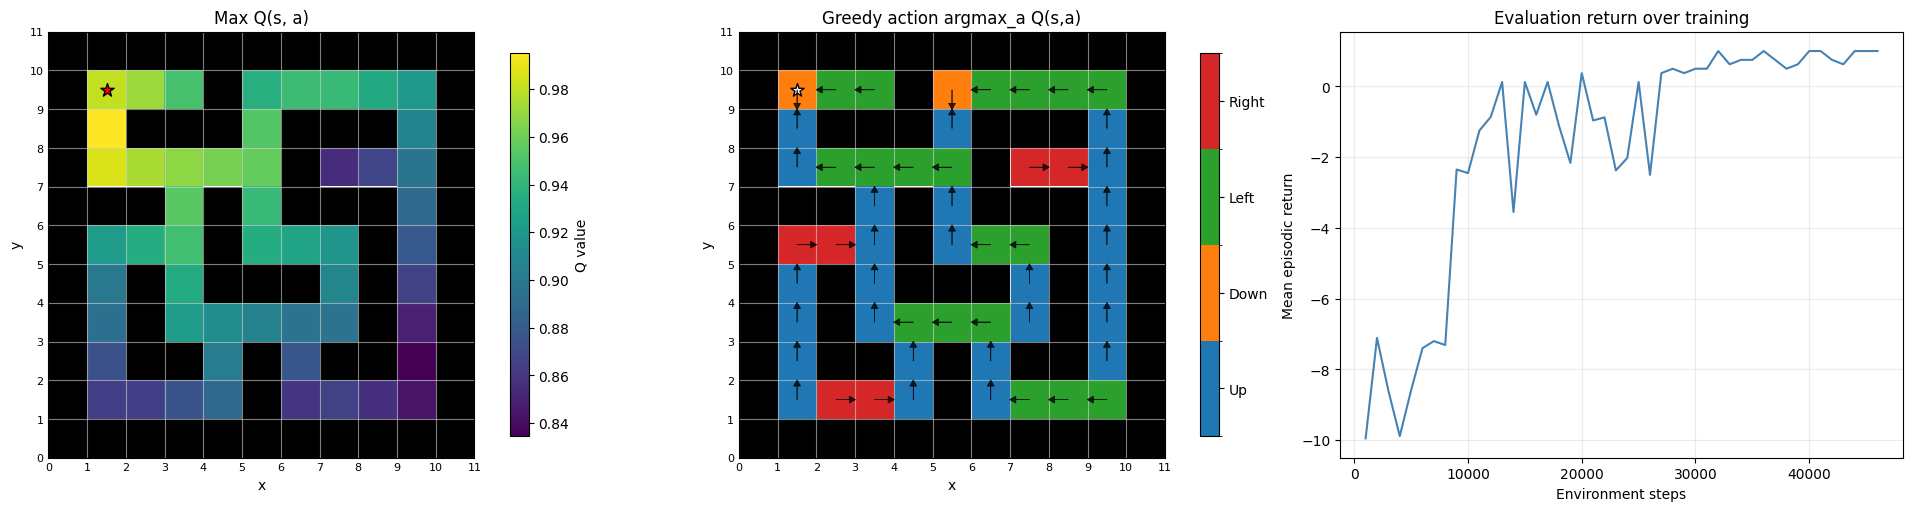

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [2.9708931 2.870038  2.7764592 2.2730372 2.1635103]
cumulative variance (first 5 dims): [0.16519605 0.3193664  0.46364707 0.56034976 0.64795774]
cos(phi(s,a), psi/task): mean=0.8556, std=0.0643


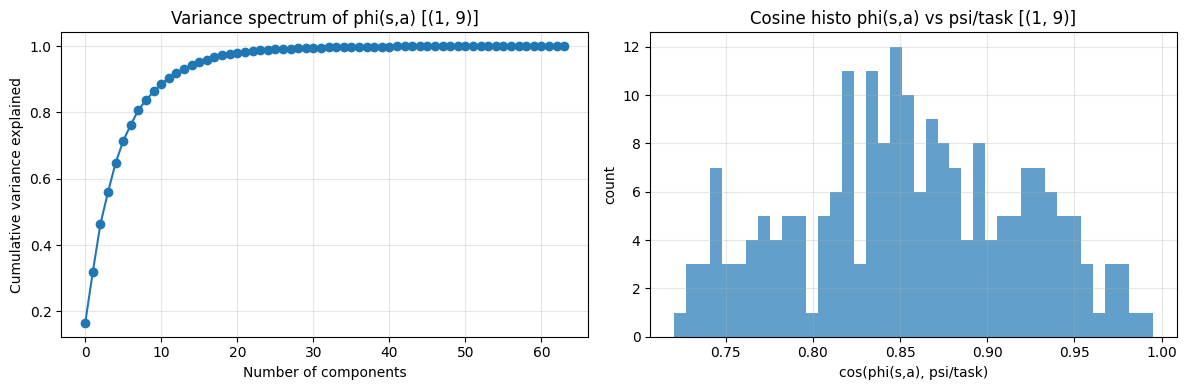


Goal embedding cosine similarity matrix:
     (1, 9)     (1, 9)
  (1, 9)      1.000      0.725
  (1, 9)      0.725      1.000

Off-diagonal mean similarity: 0.725
Off-diagonal min similarity: 0.725
Off-diagonal max similarity: 0.725


In [ ]:
SEEDS = [42, 123, 999, 354, 2944]
NUM_GOALS = 8

# Use SAME goals across seeds first, so seed averaging is cleaner.
goal_rng = np.random.default_rng(0)
GOALS = sample_goals(NUM_GOALS, cells=get_free_cells(MAZE_LAYOUT), rng=goal_rng)
print("Sampled GOALS:", GOALS)

PASS = 2
BUFFER_CAPACITY = 100000
LR = float(1e-3)
sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder"]

seed_artifacts = {}

overall_results = {
    goal: {
        "eval_returns": [[] for _ in range(PASS)],
        "min_steps": [[] for _ in range(PASS)],
        "min_time": [[] for _ in range(PASS)],
        "task_embeddings": [[] for _ in range(PASS)],
        "sa_embeddings": [[] for _ in range(PASS)],
        "sa_fixed_probe_embeddings": [[] for _ in range(PASS)],
        "sa_batches_final": [[] for _ in range(PASS)],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    seed_task_embedding_memory = []
    seen_goal_labels = []
    prev_q_net = None
    prev_q_target = None
    epsilon_reduction = False

    seed_artifacts[seed] = {
        "goals": list(GOALS),
        "passes": [
            {
                "goal_checkpoints": []
            }
            for _ in range(PASS)
        ],
        "final_q_net_state_dict": None,
        "final_q_target_state_dict": None,
        "task_embeddings_all": [],
        "seen_goal_labels": [],
    }

    for pass_num in range(PASS):
        print(f"\n===== PASS {pass_num + 1} / {PASS} =====\n")

        for goal_idx, goal in enumerate(GOALS):
            print(f"\n----- seed={seed}, goal={goal} -----\n")

            if pass_num == 0 or goal_idx == 0:
                q_net = deepcopy(q_net_base)
                q_target = deepcopy(q_target_base)
                q_target.load_state_dict(q_net.state_dict())
                for p in q_target.parameters():
                    p.requires_grad_(False)
            else:
                if prev_q_net is None or prev_q_target is None:
                    raise ValueError("Previous Q-networks are not available.")
                q_net = deepcopy(prev_q_net)
                q_target = deepcopy(prev_q_target)
                q_target.load_state_dict(q_net.state_dict())
                for p in q_target.parameters():
                    p.requires_grad_(False)

            before_ckpt = {
                "q_net_state_dict": {
                    k: v.detach().cpu() for k, v in q_net.state_dict().items()
                },
                "q_target_state_dict": {
                    k: v.detach().cpu() for k, v in q_target.state_dict().items()
                },
                "goal": goal,
                "seed": seed,
                "pass_num": pass_num,
                "goal_idx": goal_idx,
            }

            (
                q_network,
                q_target_network,
                eval_returns,
                min_steps,
                min_time,
                task_embedding,
                sa_embedding_mean,
                sa_embedding_fixed,
                sa_batch_final,
                buffer,
            ) = dqn_train(
                q_network=q_net,
                q_target_network=q_target,
                env=make_env(goal=goal),
                obs_dim=obs_dim,
                buffer_capacity=BUFFER_CAPACITY,
                lr=LR,
                goal=goal,
                device=DEVICE,
                embedding_memory=seed_task_embedding_memory,
                regulariser=None,
                reg_alpha=1,
                make_env=make_env,
                epsilon_reduction=epsilon_reduction,
            )

            after_ckpt = {
                "q_net_state_dict": {
                    k: v.detach().cpu() for k, v in q_network.state_dict().items()
                },
                "q_target_state_dict": {
                    k: v.detach().cpu() for k, v in q_target_network.state_dict().items()
                },
                "goal": goal,
                "seed": seed,
                "pass_num": pass_num,
                "goal_idx": goal_idx,
            }

            overall_results[goal]["eval_returns"][pass_num].append(eval_returns)
            overall_results[goal]["min_steps"][pass_num].append(min_steps)
            overall_results[goal]["min_time"][pass_num].append(min_time)
            overall_results[goal]["task_embeddings"][pass_num].append(task_embedding)
            overall_results[goal]["sa_embeddings"][pass_num].append(sa_embedding_mean)
            overall_results[goal]["sa_fixed_probe_embeddings"][pass_num].append(sa_embedding_fixed)
            overall_results[goal]["sa_batches_final"][pass_num].append(sa_batch_final)

            seed_artifacts[seed]["passes"][pass_num]["goal_checkpoints"].append({
                "before_train": before_ckpt,
                "after_train": after_ckpt,
                "goal": goal,
                "seed": seed,
                "pass_num": pass_num,
                "goal_idx": goal_idx,
                "eval_returns": eval_returns,
                "min_steps": min_steps,
                "min_time": min_time,
                "task_embedding": task_embedding,
                "sa_embedding_mean": sa_embedding_mean,
                "sa_embedding_fixed": sa_embedding_fixed,
                "sa_batch_final": sa_batch_final,
            })

            visualise_q_table(goal, q_network, eval_returns=eval_returns, device=DEVICE, make_env=make_env)
            visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)

            seed_task_embedding_memory.append(task_embedding)
            seen_goal_labels.append(str(goal))
            print_goal_embedding_similarity(seed_task_embedding_memory, goal_labels=seen_goal_labels)

            prev_q_net = deepcopy(q_network)
            prev_q_target = deepcopy(q_target_network)

    seed_artifacts[seed]["final_q_net_state_dict"] = {
        k: v.detach().cpu() for k, v in prev_q_net.state_dict().items()
    }
    seed_artifacts[seed]["final_q_target_state_dict"] = {
        k: v.detach().cpu() for k, v in prev_q_target.state_dict().items()
    }
    seed_artifacts[seed]["task_embeddings_all"] = deepcopy(seed_task_embedding_memory)
    seed_artifacts[seed]["seen_goal_labels"] = deepcopy(seen_goal_labels)

/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


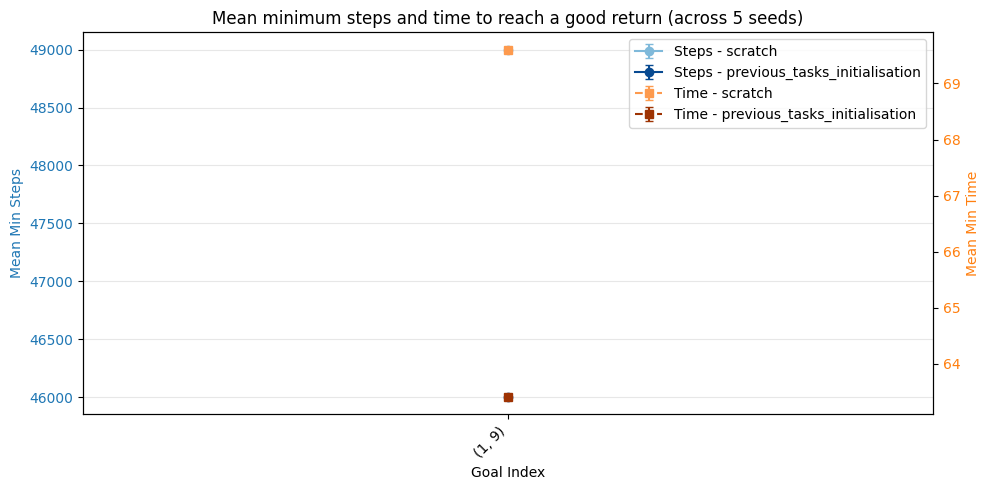

In [4]:
# --------------------------------------------------
# CHANGE THESE NAMES ONLY
# Must match the number of experiments per goal
# Example: ["seed_1", "seed_2"] or ["exp_A", "exp_B", "exp_C"]
experiment_labels = ["scratch", "previous_tasks_initialisation"]
# --------------------------------------------------

goals = list(overall_results.keys())

used_goals = []
steps_mean_per_goal = []
steps_sem_per_goal = []
time_mean_per_goal = []
time_sem_per_goal = []

for goal in goals:
    steps_pass_means = []
    steps_pass_sems = []
    time_pass_means = []
    time_pass_sems = []

    skip_goal = False

    for pass_idx in range(PASS):
        steps_raw = overall_results[goal]["min_steps"][pass_idx]
        time_raw  = overall_results[goal]["min_time"][pass_idx]

        steps_arr = np.asarray(steps_raw, dtype=float).reshape(-1)
        time_arr  = np.asarray(time_raw, dtype=float).reshape(-1)

        if steps_arr.size == 0 or time_arr.size == 0:
            print(f"[WARN] Skipping goal {goal}, pass {pass_idx}: empty data")
            skip_goal = True
            break

        steps_arr = np.array([np.nan if x is None else x for x in steps_arr], dtype=float)
        time_arr  = np.array([np.nan if x is None else x for x in time_arr], dtype=float)

        if np.all(np.isnan(steps_arr)) or np.all(np.isnan(time_arr)):
            print(f"[WARN] Skipping goal {goal}, pass {pass_idx}: no valid results")
            skip_goal = True
            break

        steps_mean = np.nanmean(steps_arr)
        time_mean  = np.nanmean(time_arr)

        steps_sem = np.nanstd(steps_arr, ddof=1) / np.sqrt(np.sum(~np.isnan(steps_arr)))
        time_sem  = np.nanstd(time_arr, ddof=1) / np.sqrt(np.sum(~np.isnan(time_arr)))

        steps_pass_means.append(steps_mean)
        steps_pass_sems.append(steps_sem)
        time_pass_means.append(time_mean)
        time_pass_sems.append(time_sem)

    if skip_goal:
        continue

    used_goals.append(goal)
    steps_mean_per_goal.append(steps_pass_means)
    steps_sem_per_goal.append(steps_pass_sems)
    time_mean_per_goal.append(time_pass_means)
    time_sem_per_goal.append(time_pass_sems)

steps_mean_per_goal = np.asarray(steps_mean_per_goal)
steps_sem_per_goal  = np.asarray(steps_sem_per_goal)
time_mean_per_goal  = np.asarray(time_mean_per_goal)
time_sem_per_goal   = np.asarray(time_sem_per_goal)

x = np.arange(len(used_goals))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_title("Mean minimum steps and time to reach a good return (across 5 seeds)")

step_colors = plt.cm.Blues(np.linspace(0.45, 0.9, PASS))
time_colors = plt.cm.Oranges(np.linspace(0.45, 0.9, PASS))

for pass_idx in range(PASS):
    ax1.errorbar(
        x,
        steps_mean_per_goal[:, pass_idx],
        yerr=steps_sem_per_goal[:, pass_idx],
        label=f"Steps - {experiment_labels[pass_idx]}",
        color=step_colors[pass_idx],
        marker="o",
        linestyle="-",
        capsize=3,
    )

ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Mean Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45, ha="right")

ax2 = ax1.twinx()

for pass_idx in range(PASS):
    ax2.errorbar(
        x,
        time_mean_per_goal[:, pass_idx],
        yerr=time_sem_per_goal[:, pass_idx],
        label=f"Time - {experiment_labels[pass_idx]}",
        color=time_colors[pass_idx],
        marker="s",
        linestyle="--",
        capsize=3,
    )

ax2.set_ylabel("Mean Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

ax1.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Backward test


================ BACKWARD EVAL SEED 42 ================


===== PASS 1 / 2 =====

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=1.000 | eval_len=11.5| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=1.000 | eval_len=10.1| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000

===== PASS 2 / 2 =====

[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.625 | eval_len=44.4| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.750 | eval_len=31.5| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


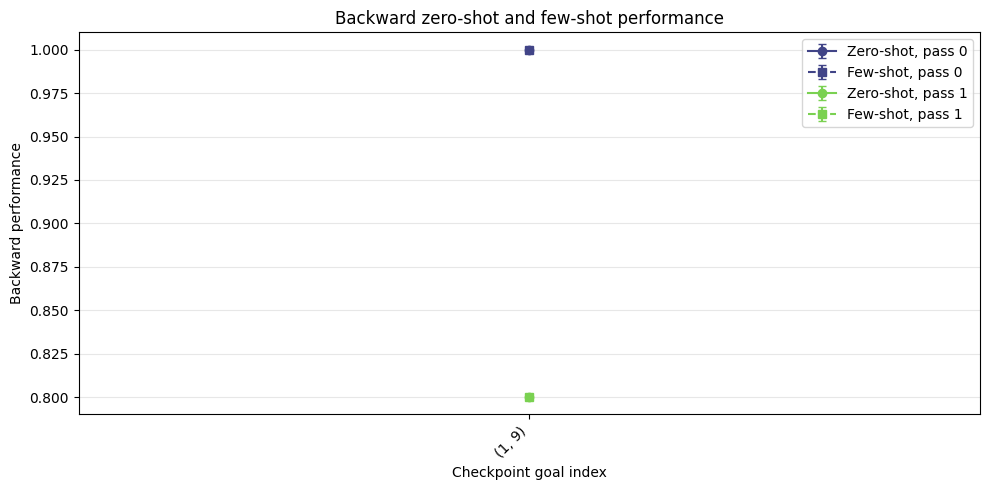

In [6]:
def build_qnet(obs_dim, num_actions, device):
    return FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(device)


def evaluate_zero_shot(q_network, goal, make_env, device, n_episodes=10):
    env = make_env(goal=goal)
    returns = []

    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            goal_t = torch.tensor(goal, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t, goal_t)
                action = int(q_vals.argmax(dim=-1).item())

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            ep_return += reward

        returns.append(ep_return)

    env.close()
    return float(np.mean(returns))


def freeze_sa_train_goal_only(q_network):
    for name, param in q_network.named_parameters():
        if "sa_encoder" in name or "phi" in name:
            param.requires_grad = False
        elif "goal_encoder" in name or "psi" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False


def evaluate_few_shot_from_seed_artifacts(
    seed_artifacts,
    seed,
    pass_num,
    checkpoint_goal_idx,
    goal,
    make_env,
    obs_dim,
    num_actions,
    device,
    embedding_memory,
    buffer_capacity,
    lr,
    few_shot_budget=2000,
):
    ckpt = seed_artifacts[seed]["passes"][pass_num]["goal_checkpoints"][checkpoint_goal_idx]["after_train"]

    q_net = build_qnet(obs_dim, num_actions, device)
    q_target = build_qnet(obs_dim, num_actions, device)

    q_net.load_state_dict(ckpt["q_net_state_dict"])
    q_target.load_state_dict(ckpt["q_target_state_dict"])

    freeze_sa_train_goal_only(q_net)

    trainable_params = [p for p in q_net.parameters() if p.requires_grad]

    adapted_q, adapted_target, *_ = dqn_train(
        q_network=q_net,
        q_target_network=q_target,
        env=make_env(goal=goal),
        obs_dim=obs_dim,
        buffer_capacity=buffer_capacity,
        lr=lr,
        goal=goal,
        device=device,
        embedding_memory=embedding_memory,
        regulariser=None,
        params=trainable_params,
        reg_alpha=1,
        make_env=make_env,
        epsilon_reduction=False,
        total_steps=few_shot_budget,
    )

    return evaluate_zero_shot(adapted_q, goal, make_env, device, n_episodes=10)


# ---------------------------------------------------------------------
# Result containers
# ---------------------------------------------------------------------

backward_results = {
    seed: {
        pass_num: {
            checkpoint_goal_idx: {
                "zero_shot": {},
                "few_shot": {},
            }
            for checkpoint_goal_idx in range(NUM_GOALS)
        }
        for pass_num in range(PASS)
    }
    for seed in SEEDS
}

backward_summary = {
    "zero_shot": np.full((len(SEEDS), PASS, NUM_GOALS), np.nan, dtype=float),
    "few_shot": np.full((len(SEEDS), PASS, NUM_GOALS), np.nan, dtype=float),
}


# ---------------------------------------------------------------------
# Backward evaluation loop
# ---------------------------------------------------------------------

for seed_i, seed in enumerate(SEEDS):
    print(f"\n================ BACKWARD EVAL SEED {seed} ================\n")
    set_seed(seed)

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # Use the stored task embeddings from training for adaptation memory
    embedding_memory = seed_artifacts[seed]["task_embeddings_all"]

    for pass_num in range(PASS):
        print(f"\n===== PASS {pass_num + 1} / {PASS} =====\n")

        for checkpoint_goal_idx in range(NUM_GOALS):
            ckpt = seed_artifacts[seed]["passes"][pass_num]["goal_checkpoints"][checkpoint_goal_idx]

            zero_vals = []
            few_vals = []

            for eval_goal_idx in range(checkpoint_goal_idx + 1):
                eval_goal = GOALS[eval_goal_idx]

                q_net = build_qnet(obs_dim, num_actions, DEVICE)
                q_net.load_state_dict(ckpt["after_train"]["q_net_state_dict"])
                q_net.eval()

                zero_shot = evaluate_zero_shot(
                    q_net,
                    eval_goal,
                    make_env,
                    DEVICE,
                    n_episodes=10,
                )

                few_shot = evaluate_few_shot_from_seed_artifacts(
                    seed_artifacts=seed_artifacts,
                    seed=seed,
                    pass_num=pass_num,
                    checkpoint_goal_idx=checkpoint_goal_idx,
                    goal=eval_goal,
                    make_env=make_env,
                    obs_dim=obs_dim,
                    num_actions=num_actions,
                    device=DEVICE,
                    embedding_memory=embedding_memory,
                    buffer_capacity=BUFFER_CAPACITY,
                    lr=LR,
                    few_shot_budget=2000,
                )

                backward_results[seed][pass_num][checkpoint_goal_idx]["zero_shot"][eval_goal_idx] = zero_shot
                backward_results[seed][pass_num][checkpoint_goal_idx]["few_shot"][eval_goal_idx] = few_shot

                zero_vals.append(zero_shot)
                few_vals.append(few_shot)

            if len(zero_vals) > 0:
                backward_summary["zero_shot"][seed_i, pass_num, checkpoint_goal_idx] = float(np.mean(zero_vals))
                backward_summary["few_shot"][seed_i, pass_num, checkpoint_goal_idx] = float(np.mean(few_vals))


# ---------------------------------------------------------------------
# Aggregate across seeds
# ---------------------------------------------------------------------

zero_mean = np.nanmean(backward_summary["zero_shot"], axis=0)
few_mean = np.nanmean(backward_summary["few_shot"], axis=0)

zero_sem = np.nanstd(backward_summary["zero_shot"], axis=0, ddof=1) / np.sqrt(
    np.sum(~np.isnan(backward_summary["zero_shot"]), axis=0)
)
few_sem = np.nanstd(backward_summary["few_shot"], axis=0, ddof=1) / np.sqrt(
    np.sum(~np.isnan(backward_summary["few_shot"]), axis=0)
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

x = np.arange(NUM_GOALS)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, PASS))

for pass_num in range(PASS):
    ax.errorbar(
        x,
        zero_mean[pass_num],
        yerr=zero_sem[pass_num],
        label=f"Zero-shot, pass {pass_num}",
        color=colors[pass_num],
        marker="o",
        linestyle="-",
        capsize=3,
    )

    ax.errorbar(
        x,
        few_mean[pass_num],
        yerr=few_sem[pass_num],
        label=f"Few-shot, pass {pass_num}",
        color=colors[pass_num],
        marker="s",
        linestyle="--",
        capsize=3,
    )

ax.set_xlabel("Checkpoint goal index")
ax.set_ylabel("Backward performance")
ax.set_title("Backward zero-shot and few-shot performance")
ax.set_xticks(x)
ax.set_xticklabels([str(g) for g in GOALS], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_net,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze_baseline.html",
    weights_his=weight_history
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])